In [1]:
# for the model
from sequence_jacobian.examples.rbc import *

# for data generation
from sequence_jacobian.utilities.shocks import simulate, get_responses
from sequence_jacobian.utilities.plotting import *

# various function imports from SSJ
from sequence_jacobian import create_model, ShockDict, AR
from sequence_jacobian.estimation import *

import numpy as np

In [2]:
# define the model here...

# or use the RBC model from the examples folder
blocks = [household, firm, mkt_clearing]
rbc_model = create_model(blocks, name="RBC")

In [3]:
# calibrated parameters
calibration = {
    "eis": 1.0,
    "frisch": 1.0,
    "delta": 0.025,
    "alpha": 0.11,
    "L": 1.0
}

In [4]:
# initial steady state values
unknowns_ss = {"vphi": 0.92, "beta": 1 / (1 + 0.01), "K": 2.0, "Z": 1.0}
targets_ss = {"goods_mkt": 0.0, "r": 0.01, "euler": 0.0, "Y": 1.0}

# solve the steady state for the given calibration
ss = rbc_model.solve_steady_state(calibration, unknowns_ss, targets_ss, solver="hybr")

In [5]:
unknowns = ["K", "L"]
targets = ["goods_mkt", "euler"]
exogenous = ["Z"]
outputs = ["K"]
T = 300

In [6]:
# define shocks using a shock dict object
shocks = ShockDict({
    "Z": AR(np.array([0.8]), 0.5)
})

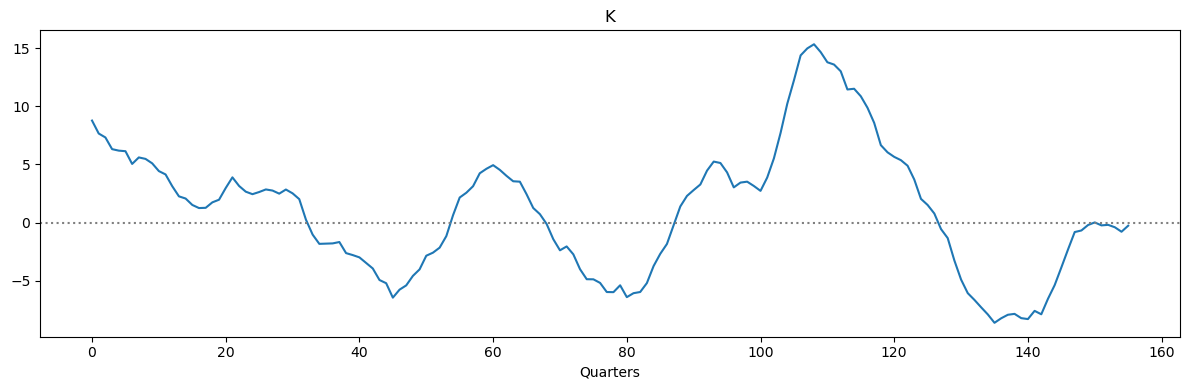

In [7]:
# generate fake data from the calibrated steady state
G = rbc_model.solve_jacobian(ss, unknowns, targets, exogenous, outputs, T=T)

impulses = shocks.generate_impulses(T)
irfs = get_responses(impulses, G)

data_simul = simulate(irfs, outputs, 156)
plt = plot_timeseries(data_simul, figsize=(12, 4))

In [8]:
def productivity_shock(params):
    return ShockDict({
        "Z": AR(np.array([params["phi_Z"]]), params["sigma_Z"])
    })

In [9]:
# construct a density model
dsge_logpdf = DensityModel(
    data_simul, ss, rbc_model, productivity_shock,
    unknowns, targets, exogenous, T=300, sigmas=np.full(1, 0.05)
)

In [10]:
prior = Prior({
    "phi_Z": Uniform(0.01, 0.99),
    "sigma_Z": InvGamma(3, 1)
})

In [11]:
mh_sampler = MetropolisHastings(dsge_logpdf, prior, step_size=0.05)
mh_sampler.sample(10000)

100%|██████████| 999/999 [00:08<00:00, 113.65it/s]


array([[0.        , 0.        ],
       [0.0774722 , 0.28668598],
       [0.0774722 , 0.28668598],
       ...,
       [0.80051572, 0.53581065],
       [0.81715864, 0.520253  ],
       [0.76769229, 0.45963143]])

In [12]:
np.mean(mh_sampler.samples, axis=0)

array([0.7904054 , 0.48096012])

In [13]:
mle = MaximumLikelihood(dsge_logpdf, prior)
res = mle.optimize("scipy_lbfgsb")

In [14]:
res.x

{'phi_Z': 0.812290330549399, 'sigma_Z': 0.4798617272931854}